<a href="https://colab.research.google.com/github/Amyriki/PHF14-LUAD-analysis/blob/main/notebooks/01_PHF14_LUAD_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PHF14 co-expression analysis in TCGA-LUAD

## Question
Which genes are most strongly correlated with PHF14 expression
in lung adenocarcinoma (LUAD)?

## Analysis plan
1. Obtain TCGA-LUAD gene expression data
2. Extract PHF14 expression
3. Calculate genome-wide correlations with PHF14
4. Identify highly correlated genes
5. Examine their chromosomal distribution
6. Investigate copy-number alterations

In [4]:
import pandas as pd

luad = pd.read_csv(
    "/content/TCGA.LUAD.sampleMap_HiSeqV2.gz",
    sep="\t"
)

luad.shape

(20530, 577)

In [5]:
luad.head()

,sample,TCGA-69-7978-01,TCGA-62-8399-01,TCGA-78-7539-01,TCGA-50-5931-11,TCGA-73-4658-01,TCGA-44-6775-01,TCGA-44-2655-01,TCGA-44-3398-01,TCGA-62-8397-01,...,TCGA-75-7025-01,TCGA-55-7726-01,TCGA-L9-A743-01,TCGA-86-8358-01,TCGA-55-6972-01,TCGA-55-7727-01,TCGA-91-6831-01,TCGA-MN-A4N4-01,TCGA-55-8302-01,TCGA-MP-A4TK-01
0,ARHGEF10L,9.9898,10.4257,9.6264,8.6835,9.2078,10.0039,9.3263,9.0249,10.5411,...,10.0905,7.5219,9.6563,9.2042,8.2127,7.2428,8.8388,9.9341,10.1696,10.1272
1,HIF3A,4.2598,11.6239,9.1362,9.4824,5.0288,4.0573,5.5335,5.7347,6.6477,...,8.0944,4.2952,5.1675,9.2442,9.0641,7.5416,3.5613,8.3457,5.5364,10.2122
2,RNF17,0.4181,0.0000,1.1231,0.8221,0.0000,1.0069,0.6021,0.0000,0.0000,...,0.4628,0.0000,0.9593,0.7339,1.0987,0.9392,0.0000,0.9715,0.0000,0.5804
3,RNF10,10.3657,11.5489,11.6692,11.7341,11.6209,11.1721,11.9169,11.3274,12.3611,...,11.3260,12.0388,11.4458,11.5642,11.5881,11.8686,12.2704,11.8150,11.7813,11.4430
4,RNF11,11.1718,11.0200,10.4679,11.6787,11.3414,11.0969,11.4044,11.4975,11.2828,...,10.8121,11.3304,10.4473,10.9991,10.0014,11.2862,11.1187,10.6101,10.5163,11.1243


In [6]:
luad.columns[:10]

Index(['sample', 'TCGA-69-7978-01', 'TCGA-62-8399-01', 'TCGA-78-7539-01',
       'TCGA-50-5931-11', 'TCGA-73-4658-01', 'TCGA-44-6775-01',
       'TCGA-44-2655-01', 'TCGA-44-3398-01', 'TCGA-62-8397-01'],
      dtype='object')

In [7]:
luad[luad["sample"] == "PHF14"]

,sample,TCGA-69-7978-01,TCGA-62-8399-01,TCGA-78-7539-01,TCGA-50-5931-11,TCGA-73-4658-01,TCGA-44-6775-01,TCGA-44-2655-01,TCGA-44-3398-01,TCGA-62-8397-01,...,TCGA-75-7025-01,TCGA-55-7726-01,TCGA-L9-A743-01,TCGA-86-8358-01,TCGA-55-6972-01,TCGA-55-7727-01,TCGA-91-6831-01,TCGA-MN-A4N4-01,TCGA-55-8302-01,TCGA-MP-A4TK-01
18535,PHF14,8.7083,10.614,10.2584,9.1296,9.4323,10.7753,9.5097,8.9864,8.8663,...,9.9229,10.6557,9.2461,11.1893,9.893,10.1094,10.5792,9.8412,9.2713,9.3184


In [8]:
tumor_cols = [
    col for col in luad.columns
    if col.endswith("-01")
]

len(tumor_cols)

515

In [9]:
luad_tumor = luad[["sample"] + tumor_cols].copy()

luad_tumor.shape

(20530, 516)

In [10]:
phf14 = luad_tumor[
    luad_tumor["sample"] == "PHF14"
][tumor_cols].iloc[0]

egfr = luad_tumor[
    luad_tumor["sample"] == "EGFR"
][tumor_cols].iloc[0]

In [11]:
phf14.shape, egfr.shape

((515,), (515,))

In [12]:
phf14.corr(egfr)

np.float64(0.18490132246094151)

In [13]:
correlations = luad_tumor[tumor_cols].corrwith(phf14, axis=1)

correlations.head()

/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,0
0,-0.080197
1,-0.030419
2,0.013800
3,0.023545
4,0.065038


In [14]:
corr_table = pd.DataFrame({
    "gene": luad_tumor["sample"],
    "r": correlations
})

corr_table = corr_table.sort_values(
    "r",
    ascending=False
)

corr_table.head(20)

,gene,r
18535,PHF14,1.000000
19688,FTSJ2,0.534195
4049,TWISTNB,0.534165
16129,USP42,0.527867
12308,RBAK,0.497638
5793,CCT6A,0.473523
859,EIF2AK1,0.470746
8834,KBTBD2,0.469905
1597,CDK13,0.468975
8688,HNRNPA2B1,0.461784


In [16]:
corr_table["r"].describe()

,r
count,20192.000000
mean,-0.006865
std,0.112525
min,-0.397286
25%,-0.081394
50%,-0.009498
75%,0.065233
max,1.000000


In [17]:
(corr_table["r"] >= 0.4).sum()

np.int64(28)

In [18]:
high_corr = corr_table[
    (corr_table["r"] >= 0.4) &
    (corr_table["gene"] != "PHF14")
].copy()

high_corr

,gene,r
19688,FTSJ2,0.534195
4049,TWISTNB,0.534165
16129,USP42,0.527867
12308,RBAK,0.497638
5793,CCT6A,0.473523
859,EIF2AK1,0.470746
8834,KBTBD2,0.469905
1597,CDK13,0.468975
8688,HNRNPA2B1,0.461784
19530,ZNF12,0.458445


In [19]:
high_corr.shape

(27, 2)

In [20]:
high_corr["gene"].tolist()

['FTSJ2',
 'TWISTNB',
 'USP42',
 'RBAK',
 'CCT6A',
 'EIF2AK1',
 'KBTBD2',
 'CDK13',
 'HNRNPA2B1',
 'ZNF12',
 'MIOS',
 'PURB',
 'PLEKHA8',
 'EIF3B',
 'KLHL7',
 'SP4',
 'SFPQ',
 'PMS2',
 'CBX3',
 'ZNF713',
 'GARS',
 'HEATR2',
 'SMARCC1',
 'RNF216',
 'SUN1',
 'EIF5B',
 'KHDRBS1']

In [21]:
print("\n".join(high_corr["gene"]))

FTSJ2
TWISTNB
USP42
RBAK
CCT6A
EIF2AK1
KBTBD2
CDK13
HNRNPA2B1
ZNF12
MIOS
PURB
PLEKHA8
EIF3B
KLHL7
SP4
SFPQ
PMS2
CBX3
ZNF713
GARS
HEATR2
SMARCC1
RNF216
SUN1
EIF5B
KHDRBS1


In [22]:
!pip -q install mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 1.1 MB/s eta 0:00:00


In [23]:
import mygene

mg = mygene.MyGeneInfo()

In [24]:
gene_info = mg.querymany(
    high_corr["gene"].tolist(),
    scopes="symbol",
    fields="symbol,genomic_pos",
    species="human"
)

gene_info[:3]

INFO:biothings.client:querying 1-27 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


[{'query': 'FTSJ2', 'notfound': True},
 {'query': 'TWISTNB', 'notfound': True},
 {'query': 'USP42',
  '_id': '84132',
  '_score': 17.540173,
  'genomic_pos': {'chr': '7',
   'end': 6164429,
   'ensemblgene': 'ENSG00000106346',
   'start': 6104755,
   'strand': 1},
  'symbol': 'USP42'}]

In [25]:
not_found = [
    x["query"]
    for x in gene_info
    if x.get("notfound", False)
]

not_found

['FTSJ2', 'TWISTNB', 'GARS', 'HEATR2']

In [26]:
for gene in not_found:
    result = mg.query(
        gene,
        fields="symbol,alias,genomic_pos",
        species="human"
    )

    print(gene, "→", result.get("symbol"), result.get("genomic_pos"))

FTSJ2 → None None
TWISTNB → None None
GARS → None None
HEATR2 → None None


In [27]:
annotation = []

for x in gene_info:
    if not x.get("notfound", False):
        pos = x.get("genomic_pos")

        if isinstance(pos, dict):
            annotation.append({
                "gene": x["query"],
                "chromosome": pos["chr"],
                "start": pos["start"],
                "end": pos["end"]
            })

annotation = pd.DataFrame(annotation)

annotation.head()

,gene,chromosome,start,end
0,USP42,7,6104755,6164429
1,RBAK,7,5045821,5069491
2,CCT6A,7,56051685,56063992
3,EIF2AK1,7,6022247,6059240
4,KBTBD2,7,32861369,32894131


In [29]:
annotation["chromosome"].value_counts()

,count
chromosome,
7,19
1,2
3,1
2,1


In [30]:
chr7_genes = annotation[
    annotation["chromosome"] == "7"
].sort_values("start")

chr7_genes

,gene,chromosome,start,end
20,SUN1,7,816591,896435
11,EIF3B,7,2354080,2380747
1,RBAK,7,5045821,5069491
19,RNF216,7,5620047,5781696
15,PMS2,7,5970925,6009130
3,EIF2AK1,7,6022247,6059240
0,USP42,7,6104755,6164429
7,ZNF12,7,6688433,6706979
8,MIOS,7,7566823,7611748
13,SP4,7,21428024,21514822


Among the 23 successfully annotated genes with PHF14 correlation r ≥ 0.4, 19 (82.6%) were located on chromosome 7, and all 19 mapped to the short arm (7p).

In [31]:
chr7_genes[["gene", "start"]]

,gene,start
20,SUN1,816591
11,EIF3B,2354080
1,RBAK,5045821
19,RNF216,5620047
15,PMS2,5970925
3,EIF2AK1,6022247
0,USP42,6104755
7,ZNF12,6688433
8,MIOS,7566823
13,SP4,21428024


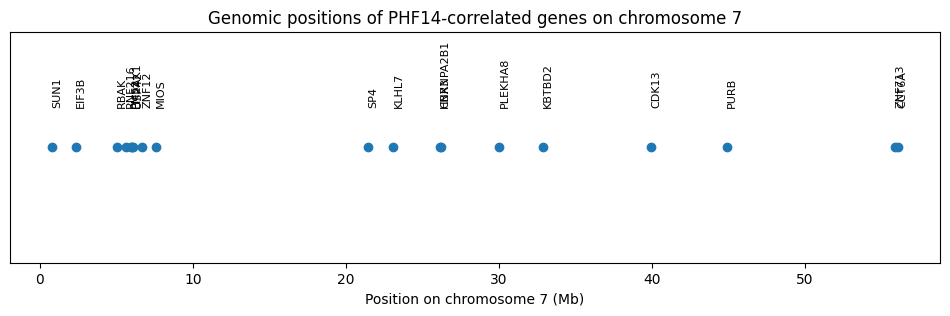

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 3))

plt.scatter(
    chr7_genes["start"] / 1e6,
    [1] * len(chr7_genes)
)

for _, row in chr7_genes.iterrows():
    plt.text(
        row["start"] / 1e6,
        1.02,
        row["gene"],
        rotation=90,
        fontsize=8
    )

plt.xlabel("Position on chromosome 7 (Mb)")
plt.yticks([])
plt.title("Genomic positions of PHF14-correlated genes on chromosome 7")

plt.show()

In [35]:
chr7_plot = chr7_genes.merge(
    high_corr,
    on="gene",
    how="left"
)

chr7_plot[["gene", "start", "r"]]

,gene,start,r
0,SUN1,816591,0.405965
1,EIF3B,2354080,0.446402
2,RBAK,5045821,0.497638
3,RNF216,5620047,0.407081
4,PMS2,5970925,0.420138
5,EIF2AK1,6022247,0.470746
6,USP42,6104755,0.527867
7,ZNF12,6688433,0.458445
8,MIOS,7566823,0.457314
9,SP4,21428024,0.431682


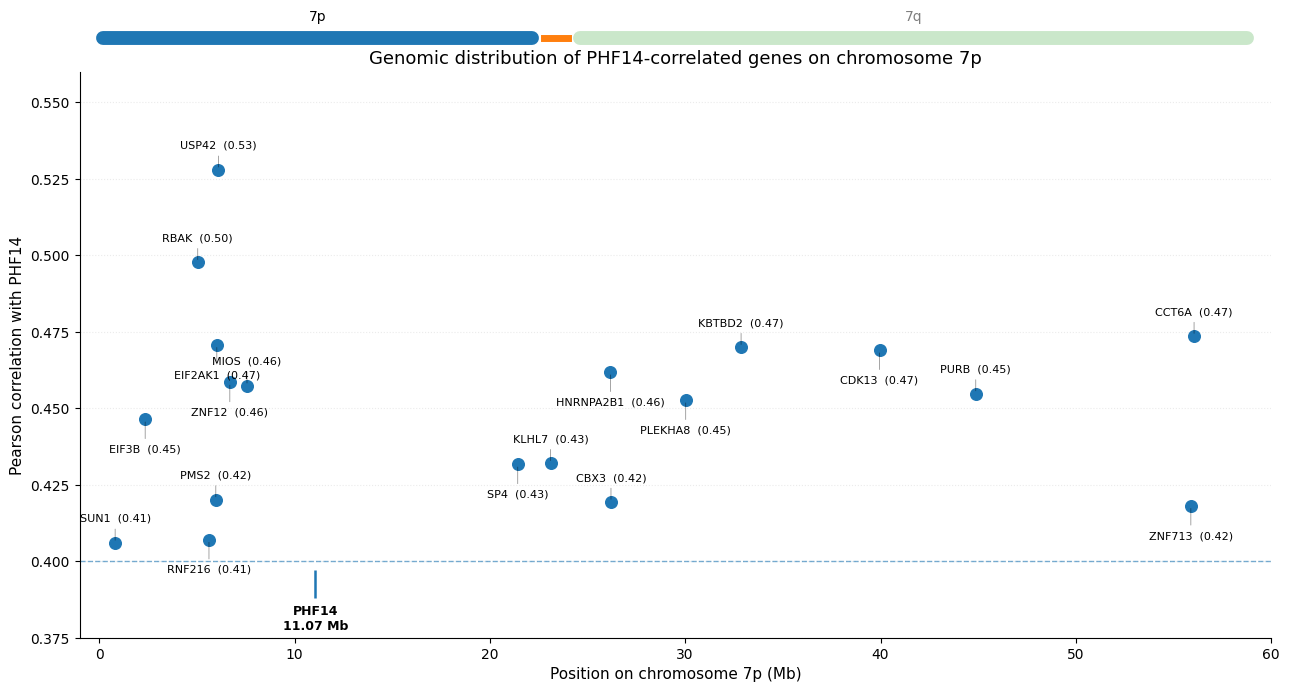

In [55]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plot_df = chr7_plot.copy()
plot_df["position_mb"] = plot_df["start"] / 1e6
plot_df = plot_df.sort_values("position_mb")

fig, ax = plt.subplots(figsize=(13, 7))

# --------------------------------------------------
# Scatter: position vs correlation
# --------------------------------------------------

ax.scatter(
    plot_df["position_mb"],
    plot_df["r"],
    s=70,
    zorder=3
)

# threshold
ax.axhline(
    0.4,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# --------------------------------------------------
# Gene labels
# Alternate labels left/right to reduce overlap
# --------------------------------------------------

for i, (_, row) in enumerate(plot_df.iterrows()):

    # alternate vertical offset
    offset = 14 if i % 2 == 0 else -18
    va = "bottom" if offset > 0 else "top"

    ax.annotate(
        f'{row["gene"]}  ({row["r"]:.2f})',
        xy=(row["position_mb"], row["r"]),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=8,
        arrowprops=dict(
            arrowstyle="-",
            linewidth=0.5,
            alpha=0.5
        )
    )

# --------------------------------------------------
# Axes
# --------------------------------------------------

ax.set_xlim(-1, 60)
ax.set_ylim(0.385, 0.56)

ax.set_xlabel(
    "Position on chromosome 7p (Mb)",
    fontsize=11
)

ax.set_ylabel(
    "Pearson correlation with PHF14",
    fontsize=11
)

ax.set_title(
    "Genomic distribution of PHF14-correlated genes on chromosome 7p",
    fontsize=13
)

# --------------------------------------------------
# Small chromosome ideogram ABOVE the plot
# --------------------------------------------------

# coordinates are in axes fraction, so it doesn't
# interfere with the correlation data
chrom_y = 1.06

# p arm
ax.plot(
    [0.02, 0.38],
    [chrom_y, chrom_y],
    transform=ax.transAxes,
    linewidth=10,
    solid_capstyle="round",
    clip_on=False
)

# centromere
ax.plot(
    [0.39, 0.41],
    [chrom_y, chrom_y],
    transform=ax.transAxes,
    linewidth=5,
    clip_on=False
)

# q arm
ax.plot(
    [0.42, 0.98],
    [chrom_y, chrom_y],
    transform=ax.transAxes,
    linewidth=10,
    solid_capstyle="round",
    alpha=0.25,
    clip_on=False
)

ax.text(
    0.20, 1.09,
    "7p",
    transform=ax.transAxes,
    ha="center",
    fontsize=10
)

ax.text(
    0.70, 1.09,
    "7q",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    alpha=0.5
)

# --------------------------------------------------
# Clean style
# --------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)

# Mark PHF14 position on the x-axis
ax.vlines(
    phf14_mb,
    ymin=0.388,
    ymax=0.397,
    linewidth=1.8
)

ax.text(
    phf14_mb,
    0.386,
    f"PHF14\n{phf14_mb:.2f} Mb",
    ha="center",
    va="top",
    fontsize=9,
    fontweight="bold"
)

ax.set_ylim(0.375, 0.56)

plt.tight_layout()
plt.show()



In [56]:
import pandas as pd

cnv = pd.read_csv(
    "/content/Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz",
    sep="\t"
)

print(cnv.shape)
cnv.head()

(24776, 517)


,Gene Symbol,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,TCGA-05-4396-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
0,ACAP3,-1,-1,-1,0,0,-1,-1,0,-1,...,0,0,0,-1,0,1,0,-1,-1,0
1,ACTRT2,-1,-1,-1,0,0,-1,-1,0,-1,...,0,0,0,-1,0,1,0,-1,-1,0
2,AGRN,-1,-1,-1,0,0,-1,-1,0,-1,...,0,0,0,-1,0,1,0,-1,-1,0
3,ANKRD65,-1,-1,-1,0,0,-1,-1,0,-1,...,0,0,0,-1,0,1,0,-1,-1,0
4,ATAD3A,-1,-1,-1,0,0,-1,-1,0,-1,...,0,0,0,-1,0,1,0,-1,-1,0


In [57]:
cnv[
    cnv["Gene Symbol"].isin(["PHF14", "EGFR"])
]

,Gene Symbol,TCGA-05-4244-01,TCGA-05-4249-01,TCGA-05-4250-01,TCGA-05-4382-01,TCGA-05-4384-01,TCGA-05-4389-01,TCGA-05-4390-01,TCGA-05-4395-01,TCGA-05-4396-01,...,TCGA-NJ-A4YG-01,TCGA-NJ-A4YI-01,TCGA-NJ-A4YP-01,TCGA-NJ-A4YQ-01,TCGA-NJ-A55A-01,TCGA-NJ-A55O-01,TCGA-NJ-A55R-01,TCGA-NJ-A7XG-01,TCGA-O1-A52J-01,TCGA-S2-AA1A-01
8855,PHF14,1,-1,1,2,1,1,1,1,0,...,0,0,0,0,0,1,0,0,1,1
9124,EGFR,-1,-1,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,1,1


In [58]:
# Extract PHF14 and EGFR CNV values
phf14_cnv = cnv[
    cnv["Gene Symbol"] == "PHF14"
].iloc[0, 1:]

egfr_cnv = cnv[
    cnv["Gene Symbol"] == "EGFR"
].iloc[0, 1:]

print("PHF14 CNV:")
print(phf14_cnv.value_counts().sort_index())

print("\nEGFR CNV:")
print(egfr_cnv.value_counts().sort_index())

PHF14 CNV:
8855
-2      2
-1     29
0     203
1     262
2      20
Name: count, dtype: int64

EGFR CNV:
9124
-2      3
-1     33
0     208
1     244
2      28
Name: count, dtype: int64


In [59]:
cnv_compare = pd.DataFrame({
    "PHF14": phf14_cnv,
    "EGFR": egfr_cnv
})

pd.crosstab(
    cnv_compare["PHF14"],
    cnv_compare["EGFR"]
)

EGFR,-2,-1,0,1,2
PHF14,,,,,
-2,1,0,0,0,1
-1,0,21,2,5,1
0,1,6,186,5,5
1,1,5,17,224,15
2,0,1,3,10,6


In [60]:
from scipy.stats import spearmanr

# Exact agreement
agreement = (cnv_compare["PHF14"] == cnv_compare["EGFR"]).mean()

# Spearman correlation
rho, p = spearmanr(
    cnv_compare["PHF14"],
    cnv_compare["EGFR"]
)

print(f"Exact CNV agreement: {agreement:.3f}")
print(f"Spearman rho: {rho:.3f}")
print(f"P-value: {p:.3e}")

Exact CNV agreement: 0.849
Spearman rho: 0.739
P-value: 3.701e-90


In [62]:
genes_7p = annotation[
    annotation["chromosome"] == "7"
]["gene"].tolist()

print(len(genes_7p))
print(genes_7p)

19
['USP42', 'RBAK', 'CCT6A', 'EIF2AK1', 'KBTBD2', 'CDK13', 'HNRNPA2B1', 'ZNF12', 'MIOS', 'PURB', 'PLEKHA8', 'EIF3B', 'KLHL7', 'SP4', 'PMS2', 'CBX3', 'ZNF713', 'RNF216', 'SUN1']


In [63]:
genes_to_check = ["PHF14", "EGFR"] + genes_7p

cnv_7p = cnv[
    cnv["Gene Symbol"].isin(genes_to_check)
].copy()

print(cnv_7p.shape)
print(cnv_7p["Gene Symbol"].tolist())

(21, 517)
['SUN1', 'EIF3B', 'RBAK', 'RNF216', 'PMS2', 'EIF2AK1', 'USP42', 'ZNF12', 'MIOS', 'PHF14', 'SP4', 'KLHL7', 'HNRNPA2B1', 'CBX3', 'PLEKHA8', 'KBTBD2', 'CDK13', 'PURB', 'EGFR', 'ZNF713', 'CCT6A']


In [64]:
from scipy.stats import spearmanr

results = []

for gene in genes_7p + ["EGFR"]:
    gene_cnv = cnv[
        cnv["Gene Symbol"] == gene
    ].iloc[0, 1:]

    rho, p = spearmanr(phf14_cnv, gene_cnv)

    results.append({
        "gene": gene,
        "rho_with_PHF14_CNV": rho,
        "p_value": p
    })

cnv_corr = pd.DataFrame(results)

cnv_corr = cnv_corr.sort_values(
    "rho_with_PHF14_CNV",
    ascending=False
)

cnv_corr

,gene,rho_with_PHF14_CNV,p_value
8,MIOS,0.965133,2.309591e-301
1,RBAK,0.958776,5.004945e-283
7,ZNF12,0.945767,3.735943e-253
0,USP42,0.945767,3.735943e-253
3,EIF2AK1,0.944828,2.722777e-251
14,PMS2,0.942605,5.207841e-247
13,SP4,0.937996,1.191032e-238
11,EIF3B,0.934586,7.178734e-233
17,RNF216,0.932003,1.073947e-228
18,SUN1,0.931393,9.833983e-228


The PHF14-associated co-expression pattern in LUAD may be partly driven by broad chromosome 7p copy-number alterations rather than reflecting direct transcriptional regulation by PHF14.

In [65]:
cnv_position = cnv_corr.merge(
    annotation[["gene", "start"]],
    on="gene",
    how="left"
)

cnv_position["position_mb"] = cnv_position["start"] / 1e6

cnv_position.sort_values("position_mb")

,gene,rho_with_PHF14_CNV,p_value,start,position_mb
9,SUN1,0.931393,9.833983e-228,816591.0,0.816591
7,EIF3B,0.934586,7.178734e-233,2354080.0,2.354080
1,RBAK,0.958776,5.004945e-283,5045821.0,5.045821
8,RNF216,0.932003,1.073947e-228,5620047.0,5.620047
5,PMS2,0.942605,5.207841e-247,5970925.0,5.970925
4,EIF2AK1,0.944828,2.722777e-251,6022247.0,6.022247
3,USP42,0.945767,3.735943e-253,6104755.0,6.104755
2,ZNF12,0.945767,3.735943e-253,6688433.0,6.688433
0,MIOS,0.965133,2.309591e-301,7566823.0,7.566823
6,SP4,0.937996,1.191032e-238,21428024.0,21.428024


In [67]:
egfr_info = mg.query(
    "symbol:EGFR",
    fields="symbol,genomic_pos",
    species="human"
)

egfr_info

{'took': 4,
 'total': 1,
 'max_score': 17.429058,
 'hits': [{'_id': '1956',
   '_score': 17.429058,
   'genomic_pos': {'chr': '7',
    'end': 55211628,
    'ensemblgene': 'ENSG00000146648',
    'start': 55018820,
    'strand': 1},
   'symbol': 'EGFR'}]}

In [68]:
egfr_start = egfr_info["hits"][0]["genomic_pos"]["start"]

cnv_position.loc[
    cnv_position["gene"] == "EGFR",
    "start"
] = egfr_start

cnv_position["position_mb"] = cnv_position["start"] / 1e6

cnv_position.sort_values("position_mb")

,gene,rho_with_PHF14_CNV,p_value,start,position_mb
9,SUN1,0.931393,9.833983e-228,816591.0,0.816591
7,EIF3B,0.934586,7.178734e-233,2354080.0,2.354080
1,RBAK,0.958776,5.004945e-283,5045821.0,5.045821
8,RNF216,0.932003,1.073947e-228,5620047.0,5.620047
5,PMS2,0.942605,5.207841e-247,5970925.0,5.970925
4,EIF2AK1,0.944828,2.722777e-251,6022247.0,6.022247
3,USP42,0.945767,3.735943e-253,6104755.0,6.104755
2,ZNF12,0.945767,3.735943e-253,6688433.0,6.688433
0,MIOS,0.965133,2.309591e-301,7566823.0,7.566823
6,SP4,0.937996,1.191032e-238,21428024.0,21.428024


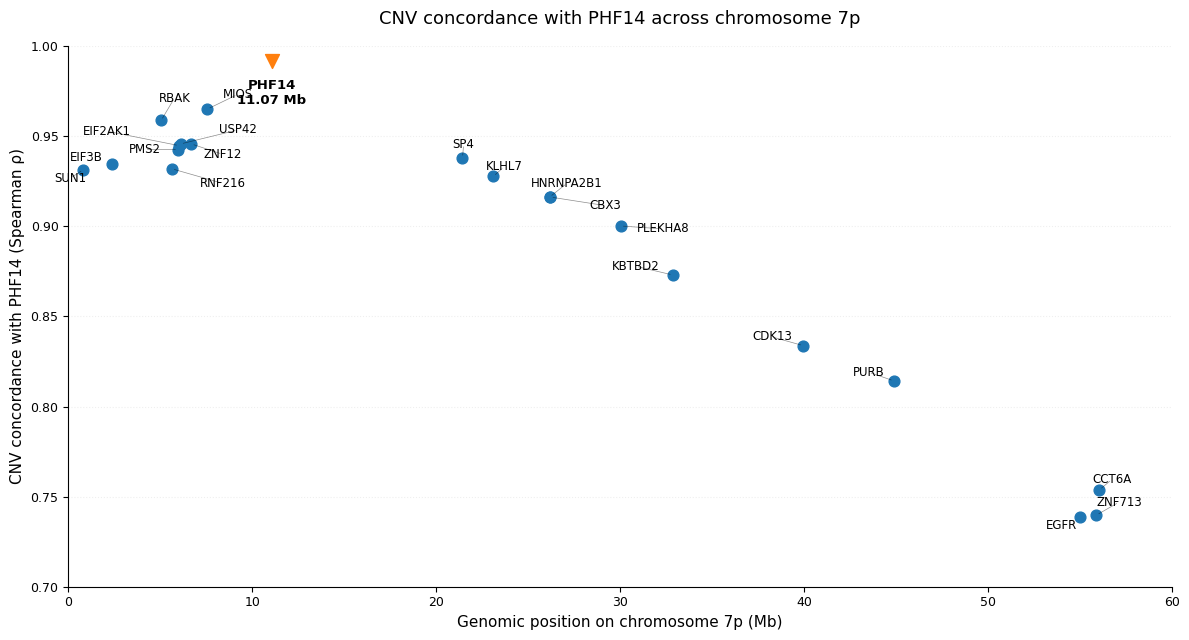

In [75]:
!pip -q install adjustText

import matplotlib.pyplot as plt
from adjustText import adjust_text

# ============================================================
# Prepare data
# ============================================================

plot_df = (
    cnv_position
    .dropna(subset=["position_mb", "rho_with_PHF14_CNV"])
    .sort_values("position_mb")
    .copy()
)

# ============================================================
# Plot
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.scatter(
    plot_df["position_mb"],
    plot_df["rho_with_PHF14_CNV"],
    s=60,
    zorder=3
)

# ============================================================
# Add gene labels
# ============================================================

texts = []

for _, row in plot_df.iterrows():

    texts.append(
        ax.text(
            row["position_mb"],
            row["rho_with_PHF14_CNV"],
            row["gene"],
            fontsize=8.5,
            ha="center",
            va="bottom"
        )
    )

# Automatically separate overlapping labels
adjust_text(
    texts,
    ax=ax,
    expand=(1.3, 1.5),
    force_text=(0.6, 0.8),
    force_points=(0.3, 0.5),
    arrowprops=dict(
        arrowstyle="-",
        linewidth=0.5,
        alpha=0.45
    )
)

# ============================================================
# PHF14 genomic landmark
# ============================================================

ax.scatter(
    phf14_mb,
    0.992,
    marker="v",
    s=100,
    zorder=5
)

ax.text(
    phf14_mb,
    0.982,
    f"PHF14\n{phf14_mb:.2f} Mb",
    ha="center",
    va="top",
    fontsize=9.5,
    fontweight="bold"
)

# ============================================================
# Axes
# ============================================================

ax.set_xlim(0, 60)
ax.set_ylim(0.70, 1.00)

ax.set_xlabel(
    "Genomic position on chromosome 7p (Mb)",
    fontsize=11
)

ax.set_ylabel(
    "CNV concordance with PHF14 (Spearman ρ)",
    fontsize=11
)

ax.set_title(
    "CNV concordance with PHF14 across chromosome 7p",
    fontsize=13,
    pad=16
)

# Clean appearance
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.2
)

ax.tick_params(
    axis="both",
    labelsize=9
)

plt.tight_layout()
plt.show()

In [77]:
from scipy.stats import spearmanr

# Distance from PHF14
cnv_position["distance_from_PHF14_mb"] = abs(
    cnv_position["position_mb"] - phf14_mb
)

# Test relationship between genomic distance and CNV concordance
distance_df = cnv_position.dropna(
    subset=["distance_from_PHF14_mb", "rho_with_PHF14_CNV"]
).copy()

rho_distance, p_distance = spearmanr(
    distance_df["distance_from_PHF14_mb"],
    distance_df["rho_with_PHF14_CNV"]
)

print(f"Spearman rho: {rho_distance:.3f}")
print(f"P-value: {p_distance:.3e}")

Spearman rho: -0.957
P-value: 3.990e-11


In [78]:
# How many genes are represented in the CNV dataset?

print("Rows:", cnv.shape[0])
print("Unique gene symbols:", cnv["Gene Symbol"].nunique())

# Check duplicated gene symbols
duplicates = cnv["Gene Symbol"].duplicated().sum()
print("Duplicated gene symbols:", duplicates)

Rows: 24776
Unique gene symbols: 24776
Duplicated gene symbols: 0


In [79]:
# Get all gene symbols from the CNV dataset

all_cnv_genes = cnv["Gene Symbol"].tolist()

print("Total genes:", len(all_cnv_genes))
print(all_cnv_genes[:10])

Total genes: 24776
['ACAP3', 'ACTRT2', 'AGRN', 'ANKRD65', 'ATAD3A', 'ATAD3B', 'ATAD3C', 'AURKAIP1', 'B3GALT6', 'C1orf159']


In [80]:
# Annotate all CNV genes in batches

all_gene_info = []

batch_size = 1000

for i in range(0, len(all_cnv_genes), batch_size):

    batch = all_cnv_genes[i:i + batch_size]

    result = mg.querymany(
        batch,
        scopes="symbol",
        fields="symbol,genomic_pos",
        species="human",
        verbose=False
    )

    all_gene_info.extend(result)

    print(
        f"Finished {min(i + batch_size, len(all_cnv_genes))} "
        f"/ {len(all_cnv_genes)} genes"
    )

print("Done!")
print("Returned records:", len(all_gene_info))

Finished 1000 / 24776 genes
Finished 2000 / 24776 genes
Finished 3000 / 24776 genes
Finished 4000 / 24776 genes
Finished 5000 / 24776 genes
Finished 6000 / 24776 genes
Finished 7000 / 24776 genes
Finished 8000 / 24776 genes
Finished 9000 / 24776 genes
Finished 10000 / 24776 genes
Finished 11000 / 24776 genes
Finished 12000 / 24776 genes
Finished 13000 / 24776 genes
Finished 14000 / 24776 genes
Finished 15000 / 24776 genes
Finished 16000 / 24776 genes
Finished 17000 / 24776 genes
Finished 18000 / 24776 genes
Finished 19000 / 24776 genes
Finished 20000 / 24776 genes
Finished 21000 / 24776 genes
Finished 22000 / 24776 genes
Finished 23000 / 24776 genes
Finished 24000 / 24776 genes
Finished 24776 / 24776 genes
Done!
Returned records: 25552


In [81]:
import pandas as pd

records = []

for item in all_gene_info:

    # Skip genes that were not found
    if item.get("notfound", False):
        continue

    pos = item.get("genomic_pos")

    # Some genes may have multiple genomic positions
    if isinstance(pos, list):
        pos = pos[0]

    if isinstance(pos, dict):
        records.append({
            "query": item.get("query"),
            "symbol": item.get("symbol"),
            "chromosome": str(pos.get("chr")),
            "start": pos.get("start"),
            "end": pos.get("end")
        })

cnv_annotation = pd.DataFrame(records)

print("Successfully annotated records:", len(cnv_annotation))
print("Unique input genes annotated:", cnv_annotation["query"].nunique())

print("\nChromosome 7 records:")
print((cnv_annotation["chromosome"] == "7").sum())

cnv_annotation.head()

Successfully annotated records: 21828
Unique input genes annotated: 21410

Chromosome 7 records:
1004


,query,symbol,chromosome,start,end
0,ACAP3,ACAP3,1,1292376,1309609
1,ACTRT2,ACTRT2,1,3021467,3022903
2,AGRN,AGRN,1,1020069,1056119
3,ANKRD65,ANKRD65,1,1415637,1421769
4,ATAD3A,ATAD3A,1,1512118,1534689


In [82]:
chr7_all = cnv_annotation[
    cnv_annotation["chromosome"] == "7"
].copy()

# Use midpoint of each gene as its genomic position
chr7_all["position_mb"] = (
    (chr7_all["start"] + chr7_all["end"]) / 2
) / 1e6

# Sort along chromosome 7
chr7_all = chr7_all.sort_values("position_mb")

print("Chromosome 7 annotated records:", len(chr7_all))
print("Unique CNV genes:", chr7_all["query"].nunique())

print("\nPosition range:")
print(chr7_all["position_mb"].describe())

chr7_all[["query", "symbol", "position_mb"]].head(10)

Chromosome 7 annotated records: 1004
Unique CNV genes: 986

Position range:
count    1004.000000
mean       85.156823
std        47.017881
min         0.226404
25%        43.847028
50%        95.344292
75%       128.712382
max       159.086325
Name: position_mb, dtype: float64


,query,symbol,position_mb
7673,FAM20C,FAM20C,0.226404
7674,PDGFA,PDGFA,0.508981
7675,PRKAR1B,PRKAR1B,0.638732
7676,SUN1,SUN1,0.856513
7677,GET4,GET4,0.886463
7678,ADAP1,ADAP1,0.925872
7679,COX19,COX19,0.970201
7680,CYP2W1,CYP2W1,0.986408
7682,MIR339,MIR339,1.022979
7681,GPR146,GPR146,1.051906


In [83]:
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

# PHF14 CNV across samples
phf14_cnv = cnv[
    cnv["Gene Symbol"] == "PHF14"
].iloc[0, 1:].astype(float)

results = []

# Go through all annotated chromosome 7 genes
for gene in chr7_all["query"].unique():

    gene_row = cnv[
        cnv["Gene Symbol"] == gene
    ]

    if gene_row.empty:
        continue

    gene_cnv = gene_row.iloc[0, 1:].astype(float)

    # Calculate CNV concordance with PHF14
    rho, p = spearmanr(phf14_cnv, gene_cnv)

    # Get genomic position
    position = chr7_all.loc[
        chr7_all["query"] == gene,
        "position_mb"
    ].iloc[0]

    results.append({
        "gene": gene,
        "position_mb": position,
        "rho_with_PHF14_CNV": rho,
        "p_value": p
    })

chr7_cnv_map = pd.DataFrame(results)

# Remove PHF14 itself
chr7_cnv_map = chr7_cnv_map[
    chr7_cnv_map["gene"] != "PHF14"
].copy()

chr7_cnv_map = chr7_cnv_map.sort_values("position_mb")

print("Genes analysed:", len(chr7_cnv_map))

chr7_cnv_map.head(10)

Genes analysed: 985


,gene,position_mb,rho_with_PHF14_CNV,p_value
0,FAM20C,0.226404,0.932273,3.998802e-229
1,PDGFA,0.508981,0.932273,3.998802e-229
2,PRKAR1B,0.638732,0.932273,3.998802e-229
3,SUN1,0.856513,0.931393,9.833983e-228
4,GET4,0.886463,0.931393,9.833983e-228
5,ADAP1,0.925872,0.931393,9.833983e-228
6,COX19,0.970201,0.931393,9.833983e-228
7,CYP2W1,0.986408,0.931393,9.833983e-228
8,MIR339,1.022979,0.931393,9.833983e-228
9,GPR146,1.051906,0.931393,9.833983e-228


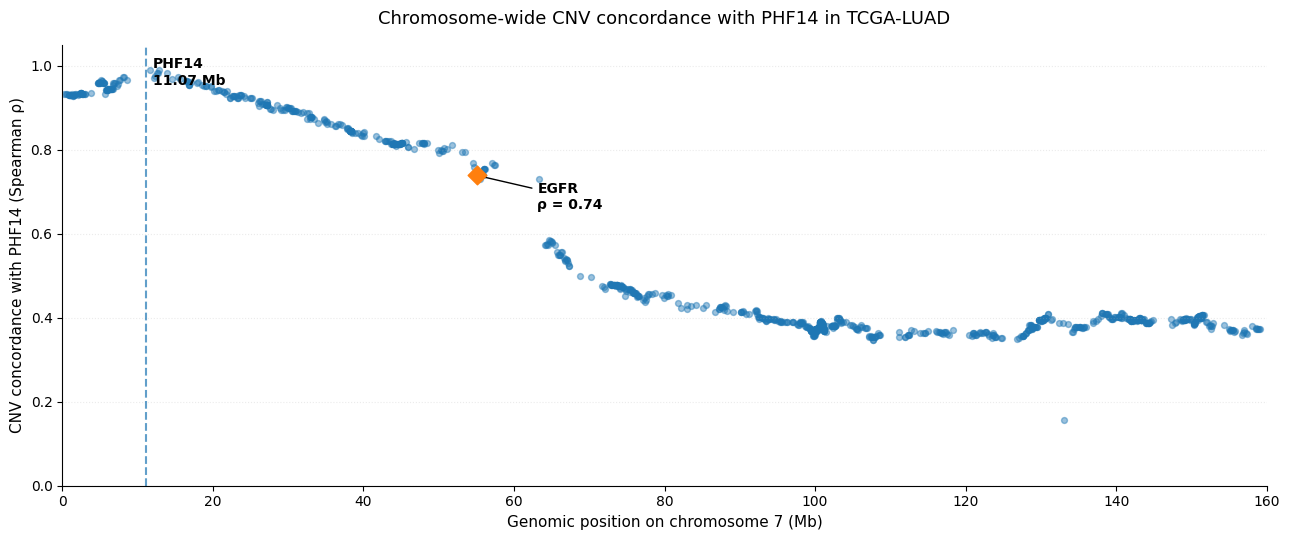

In [84]:
import matplotlib.pyplot as plt
import numpy as np

# Get EGFR
egfr_point = chr7_cnv_map[
    chr7_cnv_map["gene"] == "EGFR"
]

fig, ax = plt.subplots(figsize=(13, 5.5))

# All chromosome 7 genes
ax.scatter(
    chr7_cnv_map["position_mb"],
    chr7_cnv_map["rho_with_PHF14_CNV"],
    s=18,
    alpha=0.45
)

# PHF14 genomic position
ax.axvline(
    phf14_mb,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

ax.text(
    phf14_mb + 1,
    1.02,
    f"PHF14\n{phf14_mb:.2f} Mb",
    ha="left",
    va="top",
    fontsize=10,
    fontweight="bold"
)

# Highlight EGFR
if not egfr_point.empty:

    x_egfr = egfr_point["position_mb"].iloc[0]
    y_egfr = egfr_point["rho_with_PHF14_CNV"].iloc[0]

    ax.scatter(
        x_egfr,
        y_egfr,
        s=90,
        marker="D",
        zorder=5
    )

    ax.annotate(
        f"EGFR\nρ = {y_egfr:.2f}",
        xy=(x_egfr, y_egfr),
        xytext=(x_egfr + 8, y_egfr - 0.08),
        fontsize=10,
        fontweight="bold",
        arrowprops=dict(
            arrowstyle="-",
            linewidth=1
        )
    )

# Labels
ax.set_xlabel("Genomic position on chromosome 7 (Mb)", fontsize=11)
ax.set_ylabel("CNV concordance with PHF14 (Spearman ρ)", fontsize=11)

ax.set_title(
    "Chromosome-wide CNV concordance with PHF14 in TCGA-LUAD",
    fontsize=13,
    pad=15
)

ax.set_xlim(0, 160)

# Let the data determine a sensible lower limit
ymin = chr7_cnv_map["rho_with_PHF14_CNV"].min()
ax.set_ylim(min(ymin - 0.05, 0), 1.05)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

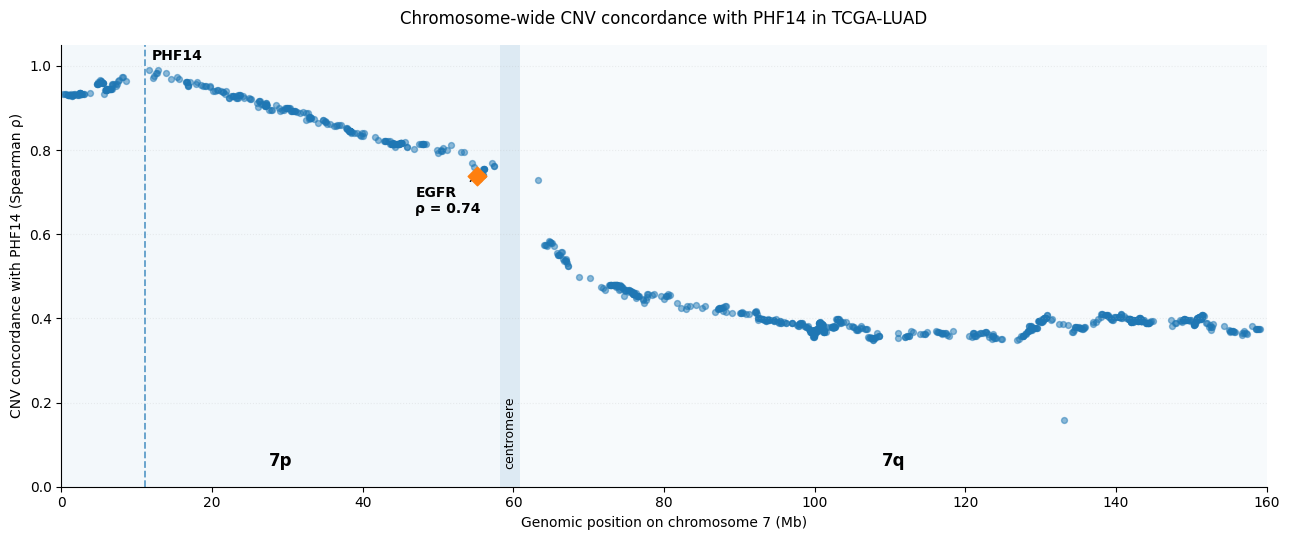

In [85]:
import matplotlib.pyplot as plt

# GRCh38 chromosome 7 centromere
cen_start = 58.169654
cen_end   = 60.828234

fig, ax = plt.subplots(figsize=(13, 5.5))

# Background chromosome-arm regions
ax.axvspan(0, cen_start, alpha=0.05)
ax.axvspan(cen_start, cen_end, alpha=0.15)
ax.axvspan(cen_end, 160, alpha=0.03)

# All chromosome 7 genes
ax.scatter(
    chr7_cnv_map["position_mb"],
    chr7_cnv_map["rho_with_PHF14_CNV"],
    s=18,
    alpha=0.5
)

# PHF14 position
ax.axvline(
    phf14_mb,
    linestyle="--",
    linewidth=1.3,
    alpha=0.7
)

ax.text(
    phf14_mb + 1,
    1.015,
    "PHF14",
    fontsize=10,
    fontweight="bold"
)

# EGFR
egfr_point = chr7_cnv_map[
    chr7_cnv_map["gene"] == "EGFR"
]

x_egfr = egfr_point["position_mb"].iloc[0]
y_egfr = egfr_point["rho_with_PHF14_CNV"].iloc[0]

ax.scatter(
    x_egfr,
    y_egfr,
    s=90,
    marker="D",
    zorder=5
)

ax.annotate(
    f"EGFR\nρ = {y_egfr:.2f}",
    xy=(x_egfr, y_egfr),
    xytext=(47, 0.65),
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="-",
        linewidth=1
    )
)

# Region labels
ax.text(
    cen_start / 2,
    0.05,
    "7p",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.text(
    (cen_start + cen_end) / 2,
    0.05,
    "centromere",
    ha="center",
    rotation=90,
    fontsize=9
)

ax.text(
    (cen_end + 160) / 2,
    0.05,
    "7q",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

ax.set_xlabel("Genomic position on chromosome 7 (Mb)")
ax.set_ylabel("CNV concordance with PHF14 (Spearman ρ)")

ax.set_title(
    "Chromosome-wide CNV concordance with PHF14 in TCGA-LUAD",
    pad=15
)

ax.set_xlim(0, 160)
ax.set_ylim(0, 1.05)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [86]:
from scipy.stats import mannwhitneyu

# Define chromosome arms
chr7_cnv_map["arm"] = "centromere"

chr7_cnv_map.loc[
    chr7_cnv_map["position_mb"] < cen_start,
    "arm"
] = "7p"

chr7_cnv_map.loc[
    chr7_cnv_map["position_mb"] > cen_end,
    "arm"
] = "7q"

# Exclude centromeric genes
arm_data = chr7_cnv_map[
    chr7_cnv_map["arm"].isin(["7p", "7q"])
].copy()

# Summary
summary = arm_data.groupby("arm")[
    "rho_with_PHF14_CNV"
].agg(["count", "mean", "median", "std"])

print(summary)

# Mann–Whitney U test
rho_7p = arm_data.loc[
    arm_data["arm"] == "7p",
    "rho_with_PHF14_CNV"
]

rho_7q = arm_data.loc[
    arm_data["arm"] == "7q",
    "rho_with_PHF14_CNV"
]

u, p = mannwhitneyu(
    rho_7p,
    rho_7q,
    alternative="two-sided"
)

print()
print(f"7p median rho: {rho_7p.median():.3f}")
print(f"7q median rho: {rho_7q.median():.3f}")
print(f"Mann–Whitney U: {u:.0f}")
print(f"P-value: {p:.3e}")

     count      mean    median       std
arm                                     
7p     320  0.887026  0.901975  0.062066
7q     665  0.402139  0.392194  0.047062

7p median rho: 0.902
7q median rho: 0.392
Mann–Whitney U: 212800
P-value: 7.890e-143


In [87]:
# Check available sample numbers first
print("PHF14 expression samples:", len(phf14))
print("EGFR expression samples:", len(egfr))

print("CNV samples:", cnv.shape[1] - 1)

PHF14 expression samples: 515
EGFR expression samples: 515
CNV samples: 516


In [88]:
# Expression sample IDs
expr_samples = tumor_cols

# CNV sample IDs
# First column is "Gene Symbol", so all remaining columns are sample IDs
cnv_samples = cnv.columns[1:].tolist()

print("Expression examples:")
print(expr_samples[:5])

print("\nCNV examples:")
print(cnv_samples[:5])

Expression examples:
['TCGA-69-7978-01', 'TCGA-62-8399-01', 'TCGA-78-7539-01', 'TCGA-73-4658-01', 'TCGA-44-6775-01']

CNV examples:
['TCGA-05-4244-01', 'TCGA-05-4249-01', 'TCGA-05-4250-01', 'TCGA-05-4382-01', 'TCGA-05-4384-01']


In [89]:
# Find samples shared by expression and CNV datasets
common_samples = [
    sample for sample in expr_samples
    if sample in cnv_samples
]

print("Expression samples:", len(expr_samples))
print("CNV samples:", len(cnv_samples))
print("Common samples:", len(common_samples))

# Check unmatched samples
expr_only = sorted(set(expr_samples) - set(cnv_samples))
cnv_only = sorted(set(cnv_samples) - set(expr_samples))

print("\nExpression only:", expr_only)
print("CNV only:", cnv_only)

Expression samples: 515
CNV samples: 516
Common samples: 512

Expression only: ['TCGA-55-7227-01', 'TCGA-55-7816-01', 'TCGA-71-8520-01']
CNV only: ['TCGA-44-3917-01', 'TCGA-44-6144-01', 'TCGA-44-A47F-01', 'TCGA-MP-A4T2-01']


In [90]:
# Extract PHF14 and EGFR expression for the 512 matched samples
phf14_expr = luad_tumor.loc[
    luad_tumor["sample"] == "PHF14",
    common_samples
].iloc[0].astype(float)

egfr_expr = luad_tumor.loc[
    luad_tumor["sample"] == "EGFR",
    common_samples
].iloc[0].astype(float)


# Extract PHF14 and EGFR CNV for the same 512 samples
phf14_cnv = cnv.loc[
    cnv["Gene Symbol"] == "PHF14",
    common_samples
].iloc[0].astype(float)

egfr_cnv = cnv.loc[
    cnv["Gene Symbol"] == "EGFR",
    common_samples
].iloc[0].astype(float)


# Combine everything into one sample-level dataframe
paired = pd.DataFrame({
    "PHF14_expression": phf14_expr,
    "PHF14_CNV": phf14_cnv,
    "EGFR_expression": egfr_expr,
    "EGFR_CNV": egfr_cnv
})

print("Shape:", paired.shape)
paired.head()

Shape: (512, 4)


,PHF14_expression,PHF14_CNV,EGFR_expression,EGFR_CNV
TCGA-69-7978-01,8.7083,-1.0,10.8992,1.0
TCGA-62-8399-01,10.6140,1.0,11.0645,1.0
TCGA-78-7539-01,10.2584,1.0,10.5117,0.0
TCGA-73-4658-01,9.4323,1.0,10.4026,1.0
TCGA-44-6775-01,10.7753,1.0,11.1912,1.0


In [91]:
from scipy.stats import spearmanr

# Remove missing values if any
phf14_test = paired[
    ["PHF14_CNV", "PHF14_expression"]
].dropna()

# Spearman correlation
rho, p = spearmanr(
    phf14_test["PHF14_CNV"],
    phf14_test["PHF14_expression"]
)

print("Samples:", len(phf14_test))
print(f"Spearman rho: {rho:.3f}")
print(f"P-value: {p:.3e}")

# Check CNV categories and expression within each group
phf14_summary = (
    phf14_test
    .groupby("PHF14_CNV")["PHF14_expression"]
    .agg(["count", "mean", "median", "std"])
)

phf14_summary

Samples: 512
Spearman rho: 0.408
P-value: 5.668e-22


,count,mean,median,std
PHF14_CNV,,,,
-2.0,2,8.995150,8.99515,0.177130
-1.0,29,9.298186,9.25070,0.611288
0.0,203,9.528503,9.50970,0.397611
1.0,258,9.840434,9.81680,0.499244
2.0,20,10.375160,10.37290,0.603800


In [92]:
# EGFR CNV vs EGFR expression
egfr_test = paired[
    ["EGFR_CNV", "EGFR_expression"]
].dropna()

rho_egfr, p_egfr = spearmanr(
    egfr_test["EGFR_CNV"],
    egfr_test["EGFR_expression"]
)

print("Samples:", len(egfr_test))
print(f"Spearman rho: {rho_egfr:.3f}")
print(f"P-value: {p_egfr:.3e}")

egfr_summary = (
    egfr_test
    .groupby("EGFR_CNV")["EGFR_expression"]
    .agg(["count", "mean", "median", "std"])
)

egfr_summary

Samples: 512
Spearman rho: 0.427
P-value: 4.228e-24


,count,mean,median,std
EGFR_CNV,,,,
-2.0,3,7.372067,8.14140,1.824316
-1.0,33,8.749636,8.94090,1.510743
0.0,208,9.436102,9.58665,1.279922
1.0,240,10.199966,10.33330,1.260198
2.0,28,12.209757,12.27145,1.664800


In [93]:
from scipy.stats import spearmanr

# PHF14 CNV vs EGFR CNV
cnv_pair = paired[
    ["PHF14_CNV", "EGFR_CNV"]
].dropna()

rho_cnv, p_cnv = spearmanr(
    cnv_pair["PHF14_CNV"],
    cnv_pair["EGFR_CNV"]
)

print("Samples:", len(cnv_pair))
print(f"PHF14 CNV vs EGFR CNV")
print(f"Spearman rho: {rho_cnv:.3f}")
print(f"P-value: {p_cnv:.3e}")

# Show the combination of CNV states
pd.crosstab(
    cnv_pair["PHF14_CNV"],
    cnv_pair["EGFR_CNV"]
)

Samples: 512
PHF14 CNV vs EGFR CNV
Spearman rho: 0.738
P-value: 4.661e-89


EGFR_CNV,-2.0,-1.0,0.0,1.0,2.0
PHF14_CNV,,,,,
-2.0,1,0,0,0,1
-1.0,0,21,2,5,1
0.0,1,6,186,5,5
1.0,1,5,17,220,15
2.0,0,1,3,10,6


co-expression → 7p clustering → shared CNV → expression consequences → PHF14–EGFR association partly explained by genomic context.

In [94]:
import statsmodels.api as sm
from scipy.stats import pearsonr

# Keep complete cases
model_df = paired[
    [
        "PHF14_expression",
        "EGFR_expression",
        "PHF14_CNV",
        "EGFR_CNV"
    ]
].dropna().copy()

# --------------------------------------------------
# 1. Raw PHF14-EGFR expression correlation
# --------------------------------------------------

r_raw, p_raw = pearsonr(
    model_df["PHF14_expression"],
    model_df["EGFR_expression"]
)

# --------------------------------------------------
# 2. Remove CNV effect from PHF14 expression
# --------------------------------------------------

X_phf14 = sm.add_constant(
    model_df[["PHF14_CNV", "EGFR_CNV"]]
)

model_phf14 = sm.OLS(
    model_df["PHF14_expression"],
    X_phf14
).fit()

phf14_residual = model_phf14.resid


# --------------------------------------------------
# 3. Remove CNV effect from EGFR expression
# --------------------------------------------------

X_egfr = sm.add_constant(
    model_df[["PHF14_CNV", "EGFR_CNV"]]
)

model_egfr = sm.OLS(
    model_df["EGFR_expression"],
    X_egfr
).fit()

egfr_residual = model_egfr.resid


# --------------------------------------------------
# 4. Correlate residual expression
# --------------------------------------------------

r_adjusted, p_adjusted = pearsonr(
    phf14_residual,
    egfr_residual
)


print("Samples:", len(model_df))

print("\nRaw expression correlation")
print(f"r = {r_raw:.3f}")
print(f"P-value = {p_raw:.3e}")

print("\nAfter adjusting for PHF14 and EGFR CNV")
print(f"r = {r_adjusted:.3f}")
print(f"P-value = {p_adjusted:.3e}")

Samples: 512

Raw expression correlation
r = 0.185
P-value = 2.589e-05

After adjusting for PHF14 and EGFR CNV
r = 0.092
P-value = 3.663e-02


The PHF14–EGFR expression correlation was substantially attenuated after adjustment for copy-number variation, suggesting that shared genomic alterations on chromosome 7p contribute to their observed co-expression.

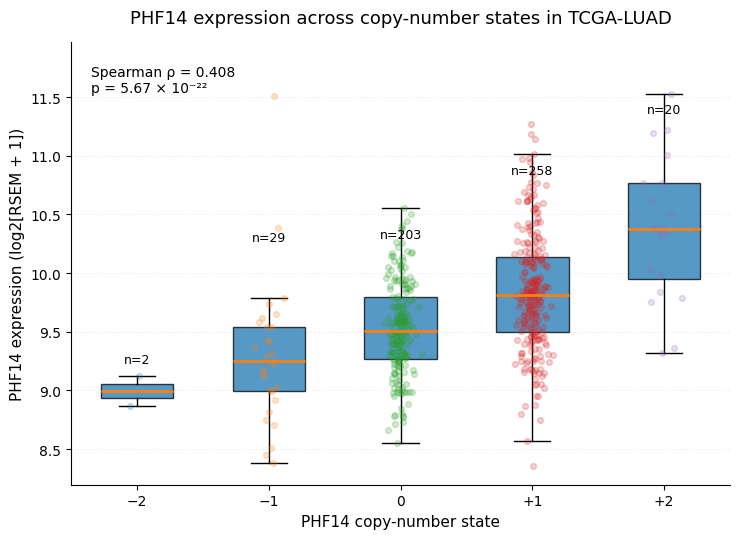

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# --------------------------------------------------
# PHF14 CNV vs expression
# --------------------------------------------------

cnv_order = [-2, -1, 0, 1, 2]

phf14_groups = [
    paired.loc[
        paired["PHF14_CNV"] == state,
        "PHF14_expression"
    ].dropna()
    for state in cnv_order
]

# Create figure
fig, ax = plt.subplots(figsize=(7.5, 5.5))


# --------------------------------------------------
# Boxplots
# --------------------------------------------------

ax.boxplot(
    phf14_groups,
    positions=cnv_order,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops={
        "linewidth": 2
    },
    boxprops={
        "alpha": 0.75
    }
)


# --------------------------------------------------
# Individual samples
# --------------------------------------------------

rng = np.random.default_rng(42)

for state, values in zip(cnv_order, phf14_groups):

    # small horizontal jitter
    x = rng.normal(
        loc=state,
        scale=0.055,
        size=len(values)
    )

    ax.scatter(
        x,
        values,
        s=18,
        alpha=0.22,
        zorder=2
    )


# --------------------------------------------------
# Sample sizes
# --------------------------------------------------

for state, values in zip(cnv_order, phf14_groups):

    # Position n label relative to each group
    y = np.percentile(values, 95) + 0.10

    ax.text(
        state,
        y,
        f"n={len(values)}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# --------------------------------------------------
# Statistics
# --------------------------------------------------

ax.text(
    0.03,
    0.95,
    "Spearman ρ = 0.408\n"
    "p = 5.67 × 10⁻²²",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)


# --------------------------------------------------
# Labels
# --------------------------------------------------

ax.set_title(
    "PHF14 expression across copy-number states in TCGA-LUAD",
    fontsize=13,
    pad=14
)

ax.set_xlabel(
    "PHF14 copy-number state",
    fontsize=11
)

ax.set_ylabel(
    "PHF14 expression (log2[RSEM + 1])",
    fontsize=11
)

ax.set_xticks(cnv_order)

ax.set_xticklabels(
    ["−2", "−1", "0", "+1", "+2"]
)


# --------------------------------------------------
# Appearance
# --------------------------------------------------

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10
)

# Add some headroom for labels
ymin, ymax = ax.get_ylim()
ax.set_ylim(
    ymin,
    ymax + (ymax - ymin) * 0.08
)

plt.tight_layout()
plt.show()

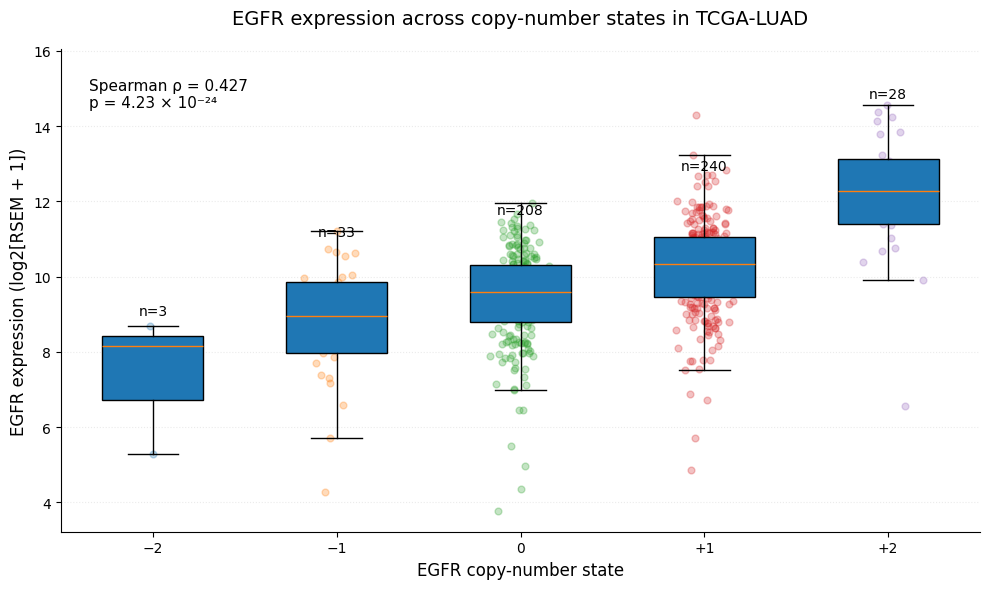

In [98]:
import numpy as np
import matplotlib.pyplot as plt

# CNV states in order
states = [-2, -1, 0, 1, 2]

# Data for each CNV state
groups = [
    paired.loc[paired["EGFR_CNV"] == state, "EGFR_expression"].dropna()
    for state in states
]

# Sample sizes
counts = [len(g) for g in groups]

fig, ax = plt.subplots(figsize=(10, 6))

# Boxplot
bp = ax.boxplot(
    groups,
    positions=range(len(states)),
    widths=0.55,
    patch_artist=True,
    showfliers=False
)

# Transparent scatter points
for i, g in enumerate(groups):
    x = np.random.normal(i, 0.06, size=len(g))
    ax.scatter(
        x,
        g,
        alpha=0.28,
        s=24
    )

# X-axis labels
ax.set_xticks(range(len(states)))
ax.set_xticklabels(["−2", "−1", "0", "+1", "+2"])

ax.set_xlabel("EGFR copy-number state", fontsize=12)
ax.set_ylabel("EGFR expression (log2[RSEM + 1])", fontsize=12)

ax.set_title(
    "EGFR expression across copy-number states in TCGA-LUAD",
    fontsize=14,
    pad=18
)

# Statistics — upper-left corner
ax.text(
    0.03,
    0.94,
    "Spearman ρ = 0.427\np = 4.23 × 10⁻²⁴",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

# Give a little extra room above the data
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + (ymax - ymin) * 0.08)

# n labels above each group
for i, (g, n) in enumerate(zip(groups, counts)):
    y = g.quantile(0.97) + 0.25

    ax.text(
        i,
        y,
        f"n={n}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Light horizontal grid
ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)

# Clean frame
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

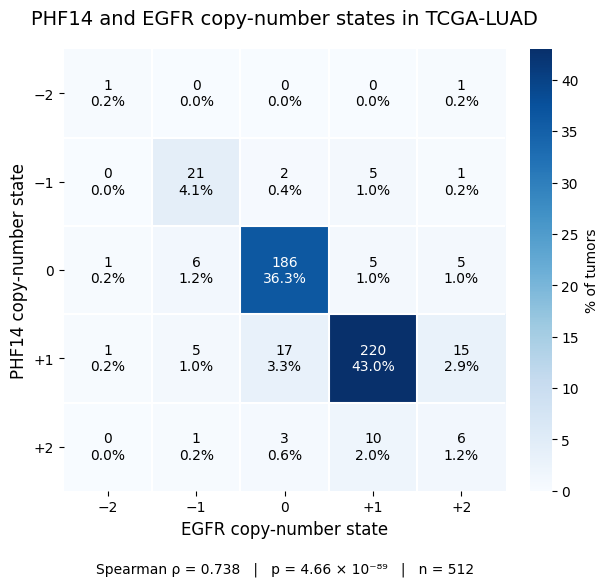

In [100]:
import pandas as pd
import matplotlib.pyplot as plt

# CNV states
states = [-2, -1, 0, 1, 2]
labels = ["−2", "−1", "0", "+1", "+2"]

# Contingency table
cnv_table = pd.crosstab(
    paired["PHF14_CNV"],
    paired["EGFR_CNV"]
).reindex(index=states, columns=states, fill_value=0)

# Percentage of all tumors
cnv_percent = cnv_table / cnv_table.values.sum() * 100

fig, ax = plt.subplots(figsize=(7, 6))

# Heatmap
im = ax.imshow(
    cnv_percent.values,
    cmap="Blues",
    aspect="equal"
)

# Axes
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

ax.set_xlabel("EGFR copy-number state", fontsize=12)
ax.set_ylabel("PHF14 copy-number state", fontsize=12)

ax.set_title(
    "PHF14 and EGFR copy-number states in TCGA-LUAD",
    fontsize=14,
    pad=18
)

# Cell annotations
max_pct = cnv_percent.values.max()

for i in range(5):
    for j in range(5):

        count = cnv_table.iloc[i, j]
        pct = cnv_percent.iloc[i, j]

        # White text only for dark cells
        text_color = "white" if pct > max_pct * 0.45 else "black"

        ax.text(
            j,
            i,
            f"{count}\n{pct:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

# Subtle white boundaries between cells
ax.set_xticks(
    [x - 0.5 for x in range(1, 5)],
    minor=True
)
ax.set_yticks(
    [y - 0.5 for y in range(1, 5)],
    minor=True
)

ax.grid(
    which="minor",
    linewidth=1.5,
    color="white"
)

ax.tick_params(which="minor", bottom=False, left=False)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label("% of tumors", fontsize=10)
cbar.outline.set_visible(False)

# Statistics
ax.text(
    0.5,
    -0.16,
    "Spearman ρ = 0.738   |   p = 4.66 × 10⁻⁸⁹   |   n = 512",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10
)

# Clean frame
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

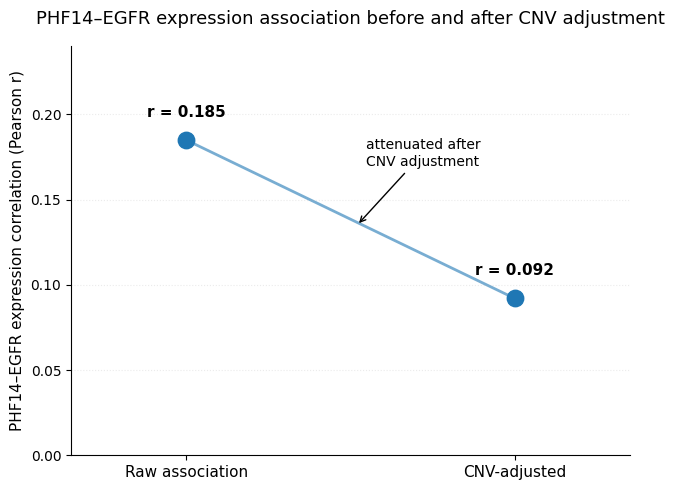

In [101]:
import matplotlib.pyplot as plt

# Correlation coefficients
labels = ["Raw", "CNV-adjusted"]
r_values = [0.185, 0.092]

fig, ax = plt.subplots(figsize=(6.5, 5))

# Connecting line
ax.plot(
    [0, 1],
    r_values,
    linewidth=2,
    alpha=0.6,
    zorder=1
)

# Points
ax.scatter(
    [0, 1],
    r_values,
    s=140,
    zorder=2
)

# Values above points
for x, r in zip([0, 1], r_values):
    ax.text(
        x,
        r + 0.012,
        f"r = {r:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Annotation showing attenuation
ax.annotate(
    "attenuated after\nCNV adjustment",
    xy=(0.52, 0.135),
    xytext=(0.72, 0.17),
    ha="center",
    fontsize=10,
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1
    )
)

# Axes
ax.set_xticks([0, 1])
ax.set_xticklabels(
    ["Raw association", "CNV-adjusted"],
    fontsize=11
)

ax.set_ylabel(
    "PHF14–EGFR expression correlation (Pearson r)",
    fontsize=11
)

ax.set_title(
    "PHF14–EGFR expression association before and after CNV adjustment",
    fontsize=13,
    pad=16
)

# Important: start from zero so the visual change isn't exaggerated
ax.set_ylim(0, 0.24)
ax.set_xlim(-0.35, 1.35)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()